# 02 — XAI and retrained full-length models with contiguous measured windows

This notebook reuses the exact sensor-7 model and 40-UGM adaptation subset from Notebook 01.

First, occlusion measures which high/low pair matters most. Then a **nested contiguous window** grows from that pair by adding one adjacent pair at a time. A new model is trained for every window while all 1,440 input positions are preserved. Outside the window, a fixed training-only mean cycle replaces the measured values. This directly answers how well a model can work with only one continuous part of the measurement cycle.

In [1]:
from pathlib import Path
import sys, json, numpy as np, matplotlib.pyplot as plt
ROOT=next(p for p in (Path.cwd().resolve(),*Path.cwd().resolve().parents)
          if (p/"Networks"/"TCOCNNv3.py").exists())
sys.path[:0]=[str(ROOT/"Networks"),str(ROOT/"Evaluation Seminar"/"Day_03"),
              str(ROOT/"Evaluation Seminar"/"Day_04")]
from day4_utils import (load_checkpoint,load_sensor_domains,scale_domain,
                        predict_ppb,fit_network)
from transfer_workflow import group_values,metrics,copy_state,save_json

OUTPUT=ROOT/"artifacts"/"seminar_day4_transfer"
model,scaler,metadata=load_checkpoint(OUTPUT/"target_finetuned")
source_model,_,source_metadata=load_checkpoint(
    ROOT/"artifacts"/"seminar_day4_global6_hpo"/"source_global6_hpo")
config=json.loads((OUTPUT/"transfer_config.json").read_text())
raw,_=load_sensor_domains(channel=0,calibration=1,gas="acetone")
target=config["target"]; domain=scale_domain(raw[target],scaler)
selected=np.isin(domain["train"]["groups"],config["selected_groups"])
adaptation={key:value[selected] for key,value in domain["train"].items()}
LR=config["selected_learning_rate"]; EPOCHS=config["fine_tune_epochs"]
print("Target:",target,"| reused UGMs:",len(np.unique(adaptation["groups"])))
print("Partial-model transfer settings: LR",LR,"| epochs",EPOCHS,
      "| subsensor",config["channel"])

Target: 84749569 | reused UGMs: 40
Partial-model transfer settings: LR 3e-07 | epochs 5 | subsensor 0


## The real sensor-7 cycles used in both notebooks

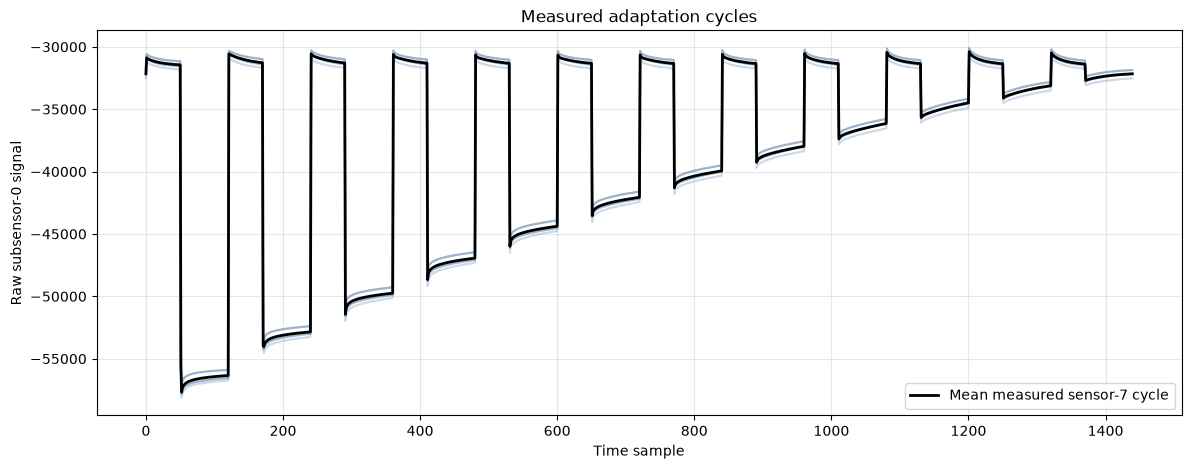

In [2]:
raw_cycles=adaptation["X"][:,0,:,0]
fig,ax=plt.subplots(figsize=(14,5))
for cycle in raw_cycles[:12]: ax.plot(cycle,color="#4c78a8",alpha=.15)
ax.plot(raw_cycles.mean(0),color="black",lw=2,label="Mean measured sensor-7 cycle")
ax.set(title="Measured adaptation cycles",xlabel="Time sample",
       ylabel="Raw subsensor-0 signal")
ax.legend(); ax.grid(True,alpha=.3); plt.show()

## Occlusion and one scatter per held-out pair

Each of the 12 physical parts contains 50 high-temperature and 70 low-temperature samples. Importance is measured on adaptation data; scatter plots use validation UGMs.

In [3]:
PAIR=120; N_PAIRS=adaptation["X_z"].shape[2]//PAIR
reference=adaptation["X_z"].mean(0,keepdims=True)
baseline=predict_ppb(model,adaptation,scaler)
effects=[]
for pair in range(N_PAIRS):
    held=adaptation["X_z"].copy()
    held[:,:,pair*PAIR:(pair+1)*PAIR,:]=reference[:,:,pair*PAIR:(pair+1)*PAIR,:]
    effects.append(baseline-predict_ppb(model,{"X_z":held},scaler))
effects=np.stack(effects,axis=1)
importance=np.asarray([
    np.mean([np.abs(effects[adaptation["groups"]==group,pair]).mean()
             for group in np.unique(adaptation["groups"])])
    for pair in range(N_PAIRS)])
start_pair=int(np.argmax(importance))

occlusion_rows=[]; scatter_values=[]
for pair in range(N_PAIRS):
    held=domain["val"]["X_z"].copy()
    held[:,:,pair*PAIR:(pair+1)*PAIR,:]=reference[:,:,pair*PAIR:(pair+1)*PAIR,:]
    pred=predict_ppb(model,{"X_z":held},scaler)
    occlusion_rows.append({"held_out_pair":pair+1,
                           **metrics(domain["val"]["y"],pred,
                                     domain["val"]["groups"])})
    scatter_values.append(group_values(domain["val"]["y"],pred,
                                       domain["val"]["groups"]))
print("Most important starting pair:",start_pair+1)

Most important starting pair: 1


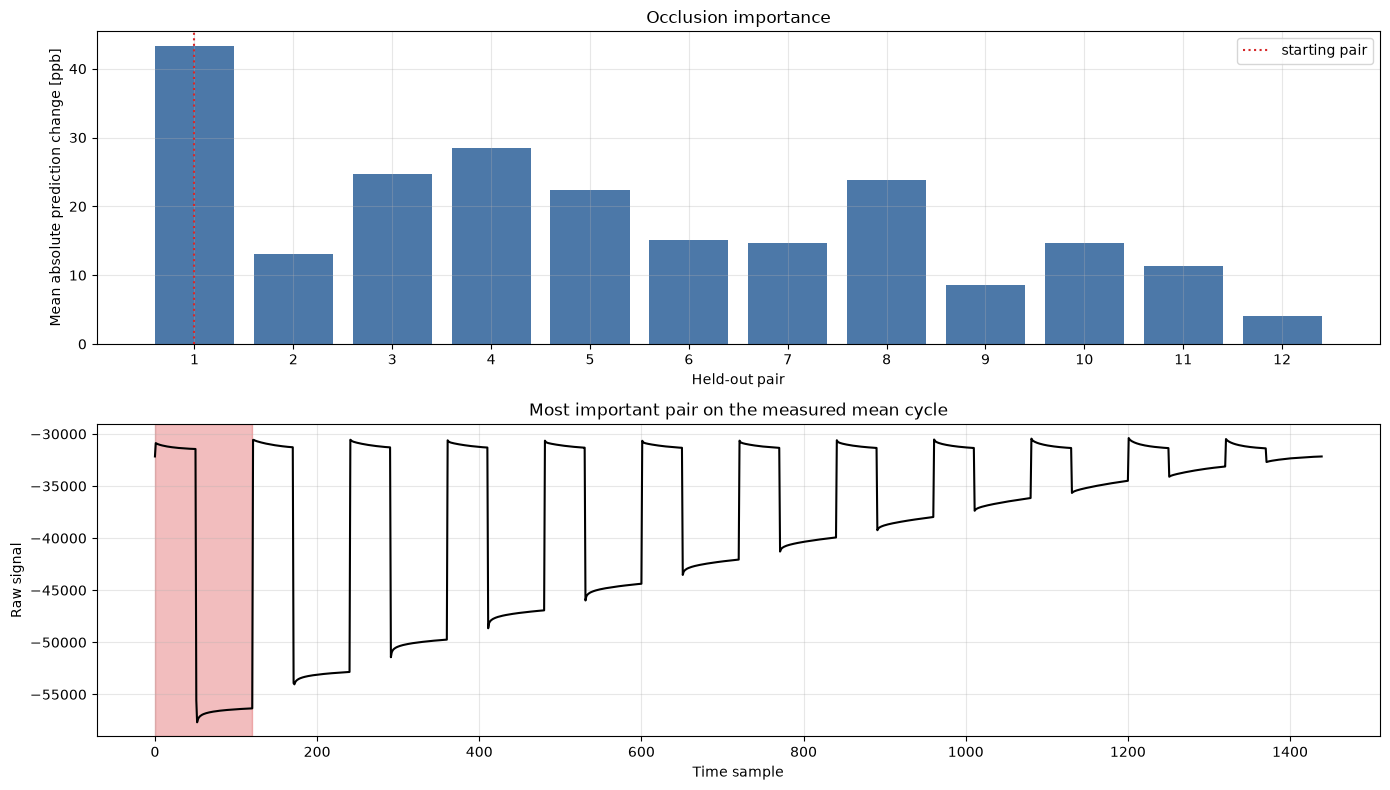

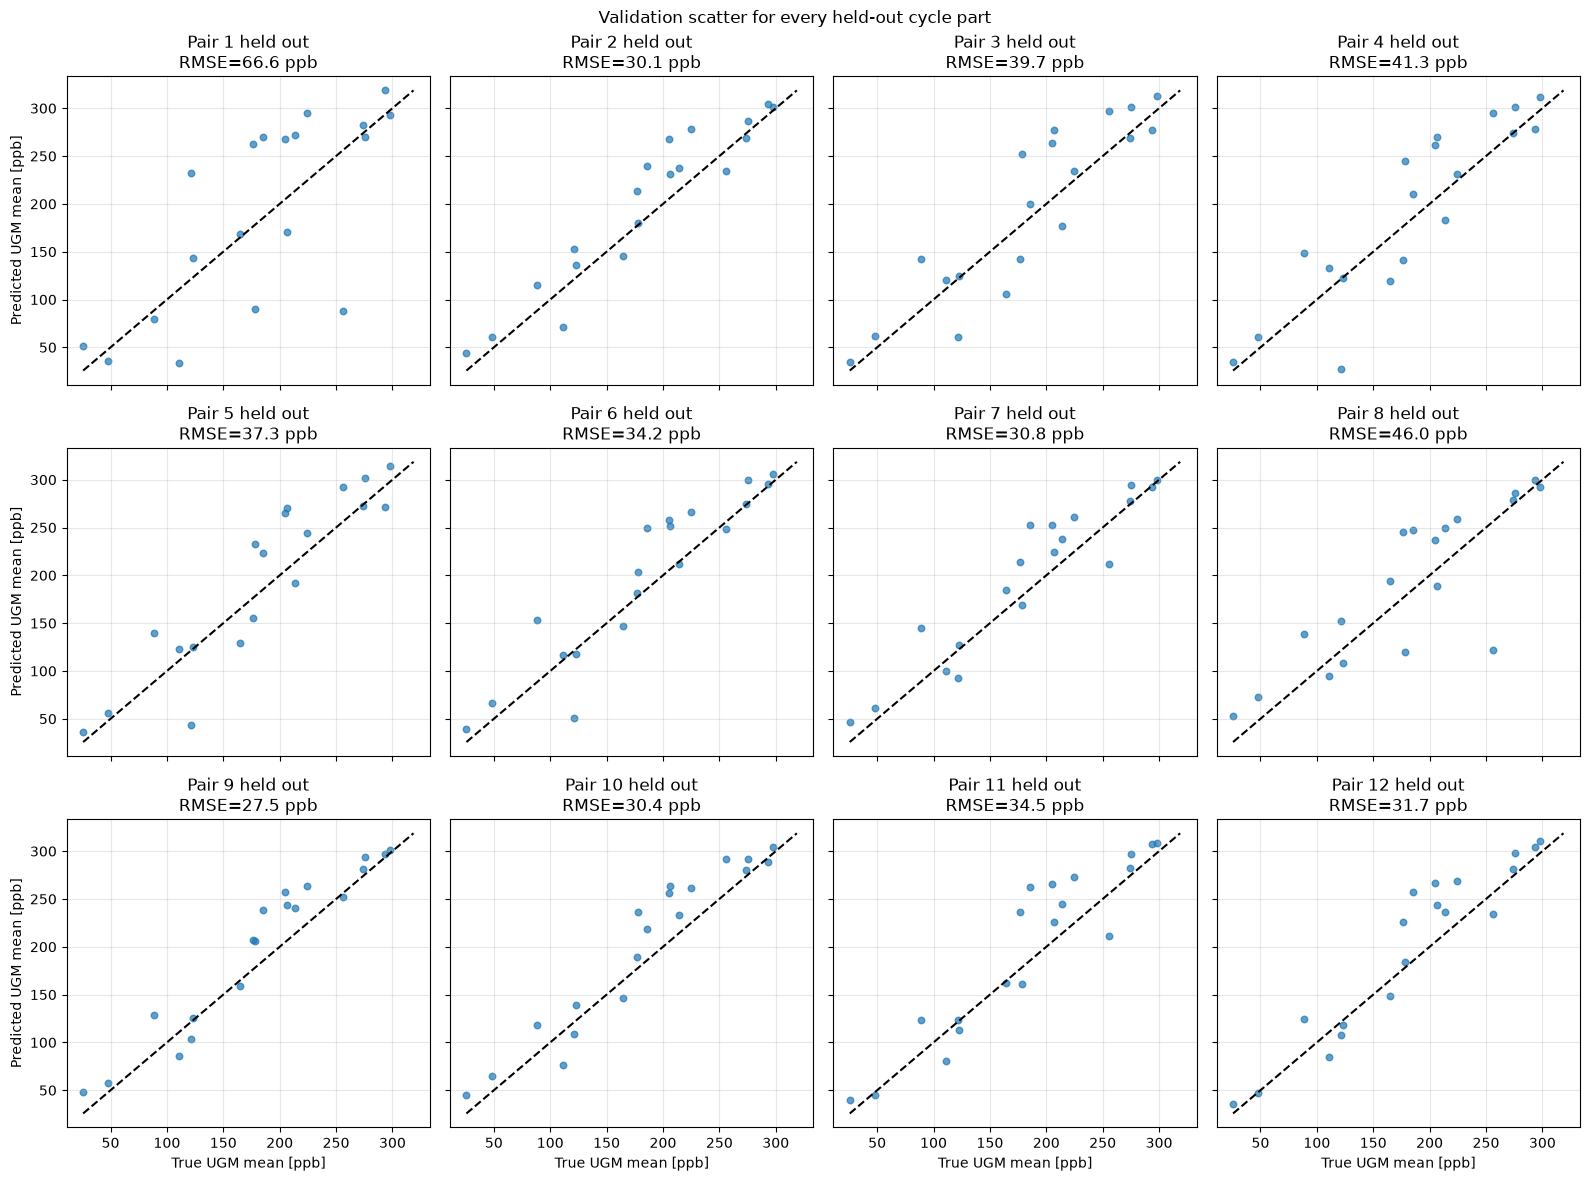

In [4]:
fig,axes=plt.subplots(2,1,figsize=(14,8))
axes[0].bar(np.arange(1,N_PAIRS+1),importance,color="#4c78a8")
axes[0].axvline(start_pair+1,color="#d62728",ls=":",label="starting pair")
axes[0].set(title="Occlusion importance",xlabel="Held-out pair",
            ylabel="Mean absolute prediction change [ppb]",
            xticks=np.arange(1,N_PAIRS+1)); axes[0].legend()
axes[1].plot(raw_cycles.mean(0),color="black")
axes[1].axvspan(start_pair*PAIR,(start_pair+1)*PAIR,color="#d62728",alpha=.3)
axes[1].set(title="Most important pair on the measured mean cycle",
            xlabel="Time sample",ylabel="Raw signal")
for ax in axes: ax.grid(True,alpha=.3)
plt.tight_layout(); plt.show()

lo=min(min(a.min(),b.min()) for a,b in scatter_values)
hi=max(max(a.max(),b.max()) for a,b in scatter_values)
fig,axes=plt.subplots(3,4,figsize=(16,12),sharex=True,sharey=True)
for pair,ax in enumerate(axes.ravel()):
    truth,pred=scatter_values[pair]
    ax.scatter(truth,pred,s=22,alpha=.7); ax.plot([lo,hi],[lo,hi],"k--")
    ax.set(title=f"Pair {pair+1} held out\n"
                 f"RMSE={occlusion_rows[pair]['UGM_RMSE_ppb']:.1f} ppb")
    ax.grid(True,alpha=.3)
for ax in axes[-1]: ax.set_xlabel("True UGM mean [ppb]")
for ax in axes[:,0]: ax.set_ylabel("Predicted UGM mean [ppb]")
fig.suptitle("Validation scatter for every held-out cycle part")
plt.tight_layout(); plt.show()

## Build one nested, contiguous window

The first window is the most important pair. At each step, only its immediate left or right neighbor may be added. The neighbor with the larger occlusion importance is chosen. Thus every larger input contains the complete previous input and never becomes fragmented.

[{'retained_pairs': 1, 'first_pair': 1, 'last_pair': 1, 'samples': 120}, {'retained_pairs': 2, 'first_pair': 1, 'last_pair': 2, 'samples': 240}, {'retained_pairs': 3, 'first_pair': 1, 'last_pair': 3, 'samples': 360}, {'retained_pairs': 4, 'first_pair': 1, 'last_pair': 4, 'samples': 480}, {'retained_pairs': 5, 'first_pair': 1, 'last_pair': 5, 'samples': 600}, {'retained_pairs': 6, 'first_pair': 1, 'last_pair': 6, 'samples': 720}, {'retained_pairs': 7, 'first_pair': 1, 'last_pair': 7, 'samples': 840}, {'retained_pairs': 8, 'first_pair': 1, 'last_pair': 8, 'samples': 960}, {'retained_pairs': 9, 'first_pair': 1, 'last_pair': 9, 'samples': 1080}, {'retained_pairs': 10, 'first_pair': 1, 'last_pair': 10, 'samples': 1200}, {'retained_pairs': 11, 'first_pair': 1, 'last_pair': 11, 'samples': 1320}, {'retained_pairs': 12, 'first_pair': 1, 'last_pair': 12, 'samples': 1440}]


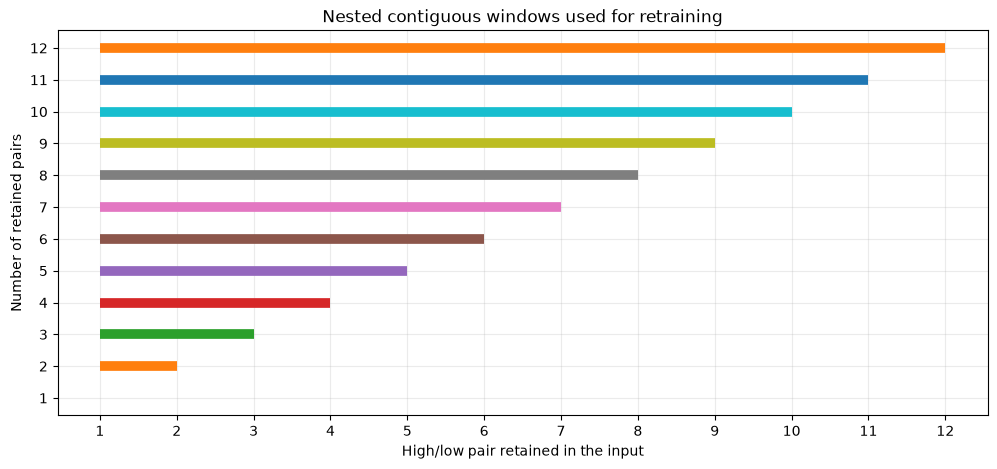

In [5]:
windows=[(start_pair,start_pair)]
left=right=start_pair
while right-left+1<N_PAIRS:
    options=[]
    if left>0: options.append((importance[left-1],left-1,"left"))
    if right<N_PAIRS-1: options.append((importance[right+1],right+1,"right"))
    _,pair,direction=max(options,key=lambda item:item[0])
    if direction=="left": left=pair
    else: right=pair
    windows.append((left,right))

window_rows=[{"retained_pairs":i+1,"first_pair":left+1,"last_pair":right+1,
              "samples":(right-left+1)*PAIR}
             for i,(left,right) in enumerate(windows)]
try:
    import pandas as pd
    display(pd.DataFrame(window_rows))
except ImportError:
    print(window_rows)

fig,ax=plt.subplots(figsize=(12,5))
for row,(left,right) in enumerate(windows):
    ax.plot([left+1,right+1],[row+1,row+1],lw=7,solid_capstyle="butt")
ax.set(title="Nested contiguous windows used for retraining",
       xlabel="High/low pair retained in the input",
       ylabel="Number of retained pairs",
       xticks=np.arange(1,N_PAIRS+1),yticks=np.arange(1,N_PAIRS+1))
ax.grid(True,alpha=.25); plt.show()

## Retrain full-length inputs with a contiguous measured window

Every input remains (1, 1440, 1). Selected adjacent pairs contain measured values; all other positions contain the same mean cycle computed only from the adaptation training set. Validation and test values never enter that mean.

Each model starts from the saved Global-6 weights. The old five-epoch, 3e-7 schedule was designed for intact cycles and can underfit masked inputs. Here each window gets 30 epochs with learning rates 1e-6 and 1e-5; validation selects the learning rate and checkpoint. BatchNorm statistics remain frozen. Test is evaluated only after every choice is frozen. Results are conditional on this small search, not a proof of the maximum information in a window.

In [6]:
partial_rows = []
partial_predictions = {}
partial_models = {}
training_histories = {}
search_rows = []
MASKED_LRS = [1e-6, 1e-5]
MASKED_EPOCHS = 30
reference = adaptation["X_z"].mean(axis=0, keepdims=True)

def masked_split(original, begin, end):
    values = np.broadcast_to(reference, original["X_z"].shape).copy()
    values[:, :, begin:end, :] = original["X_z"][:, :, begin:end, :]
    assert values.shape[1:] == (1, 1440, 1)
    return {**original, "X_z": values}

for count, (left, right) in enumerate(windows, 1):
    begin, end = left * PAIR, (right + 1) * PAIR
    masked = {
        "train": masked_split(adaptation, begin, end),
        "val": masked_split(domain["val"], begin, end),
    }
    best_score = float("inf")
    for lr in MASKED_LRS:
        params = {**source_metadata["params"], "initial_learning_rate": lr}
        partial, history, info = fit_network(
            masked, params, epochs=MASKED_EPOCHS,
            initial=copy_state(source_model), freeze_batchnorm=True,
            restore_best=True, use_validation=True,
            lr_schedule="constant", seed=42, verbose=False)
        pred = predict_ppb(partial, masked["val"], scaler)
        score = metrics(domain["val"]["y"], pred, domain["val"]["groups"])
        search_rows.append({"retained_pairs": count, "learning_rate": lr,
                            "best_epoch": info["best_epoch"], **score})
        if score["UGM_RMSE_ppb"] < best_score:
            best_score = score["UGM_RMSE_ppb"]
            partial_models[count] = partial
            training_histories[count] = history
            partial_predictions[(count, "val")] = pred
            chosen = {"learning_rate": lr, "best_epoch": info["best_epoch"]}
    for split in ["train", "val"]:
        original = adaptation if split == "train" else domain["val"]
        pred = predict_ppb(partial_models[count], masked[split], scaler)
        partial_rows.append({
            "split": split, "retained_pairs": count,
            "first_pair": left + 1, "last_pair": right + 1,
            "samples": end - begin, "input_samples": 1440,
            "seconds_at_10_Hz": (end - begin) / 10, **chosen,
            **metrics(original["y"], pred, original["groups"])})
    print(f"Window {count}/12: pairs {left+1}-{right+1}, "
          f"LR={chosen['learning_rate']:g}, epoch={chosen['best_epoch']}")

# Freeze all learning rates/checkpoints before reading test predictions.
for count, (left, right) in enumerate(windows, 1):
    test_input = masked_split(domain["test"], left * PAIR, (right + 1) * PAIR)
    pred = predict_ppb(partial_models[count], test_input, scaler)
    partial_predictions[(count, "test")] = pred
    selected_row = next(r for r in partial_rows
                        if r["retained_pairs"] == count and r["split"] == "val")
    partial_rows.append({**selected_row, "split": "test",
                        **metrics(domain["test"]["y"], pred, domain["test"]["groups"])})


Window 1/12: pairs 1-1, LR=1e-05, epoch=8
Window 2/12: pairs 1-2, LR=1e-05, epoch=7
Window 3/12: pairs 1-3, LR=1e-06, epoch=29
Window 4/12: pairs 1-4, LR=1e-06, epoch=27
Window 5/12: pairs 1-5, LR=1e-06, epoch=28
Window 6/12: pairs 1-6, LR=1e-06, epoch=28
Window 7/12: pairs 1-7, LR=1e-06, epoch=29
Window 8/12: pairs 1-8, LR=1e-06, epoch=29
Window 9/12: pairs 1-9, LR=1e-06, epoch=30
Window 10/12: pairs 1-10, LR=1e-06, epoch=29
Window 11/12: pairs 1-11, LR=1e-06, epoch=28
Window 12/12: pairs 1-12, LR=1e-06, epoch=29


## How much continuous cycle does the model need?

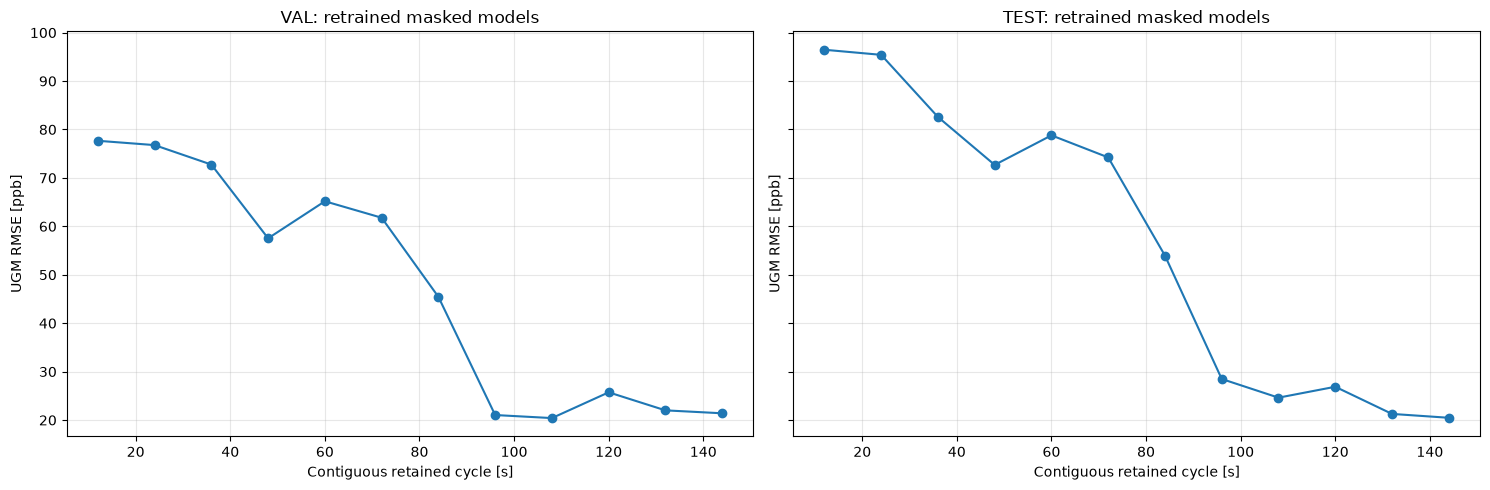

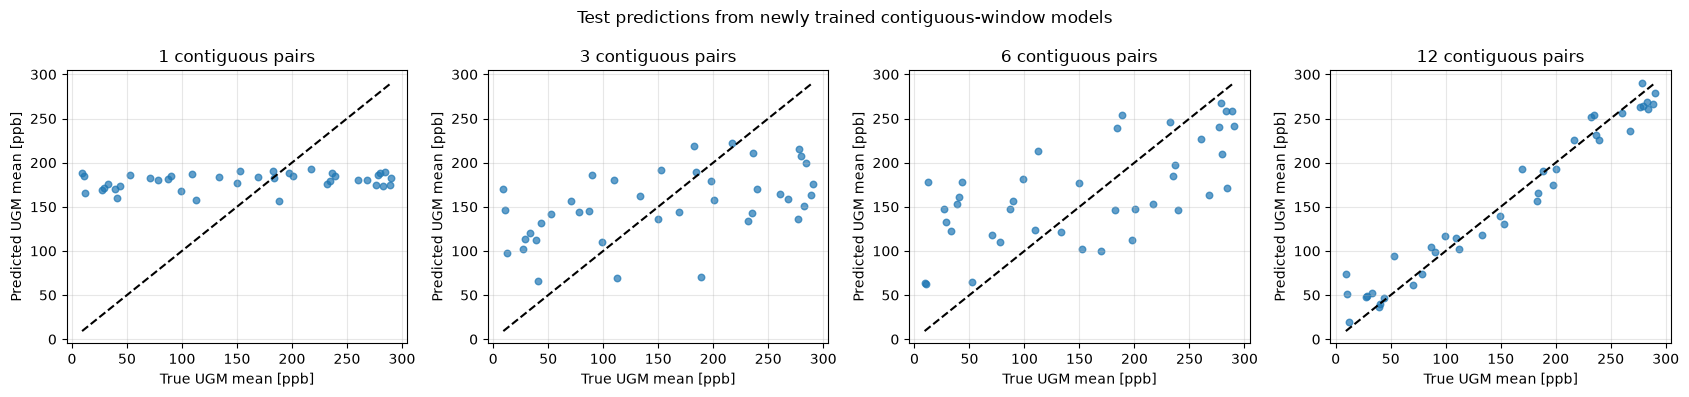

Saved XAI output: \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_transfer\xai_occlusion.json


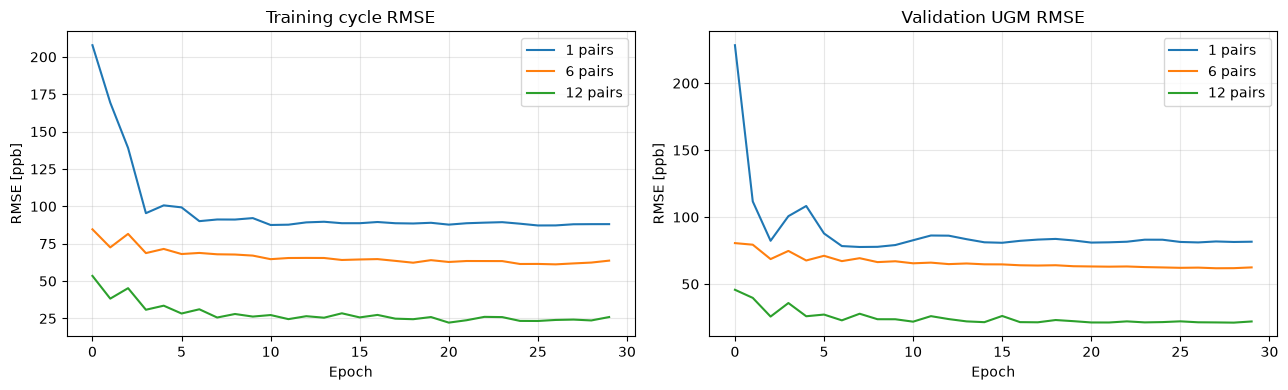

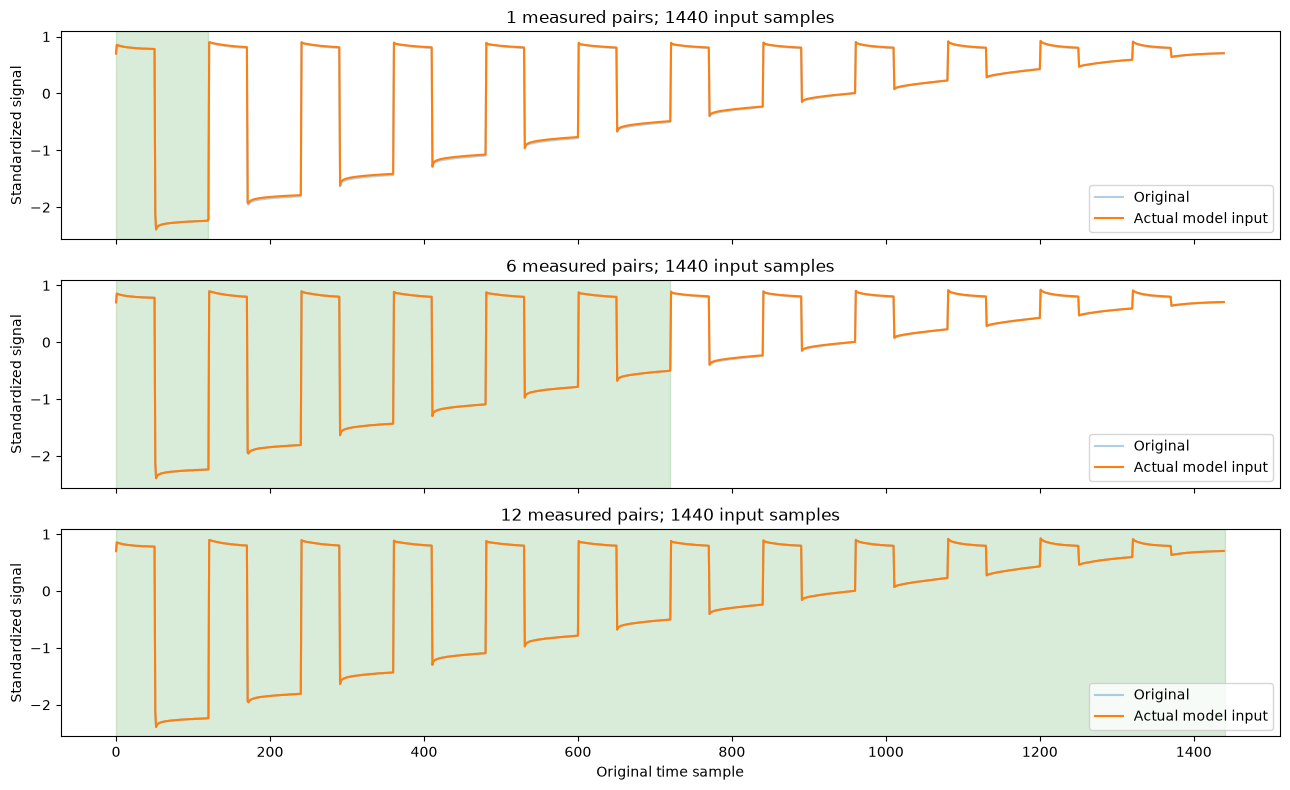

In [7]:
fig,axes=plt.subplots(1,2,figsize=(15,5),sharey=True)
for ax,split in zip(axes,["val","test"]):
    rows=[row for row in partial_rows if row["split"]==split]
    ax.plot([row["seconds_at_10_Hz"] for row in rows],
            [row["UGM_RMSE_ppb"] for row in rows],marker="o")
    ax.set(title=f"{split.upper()}: retrained masked models",
           xlabel="Contiguous retained cycle [s]",ylabel="UGM RMSE [ppb]")
    ax.grid(True,alpha=.3)
plt.tight_layout(); plt.show()

selected_counts=sorted(set([1,3,6,N_PAIRS]))
vals={f"{count} contiguous pairs":partial_predictions[(count,"test")]
      for count in selected_counts}
truth_groups=domain["test"]["groups"]
grouped={name:group_values(domain["test"]["y"],pred,truth_groups)
         for name,pred in vals.items()}
lo=min(min(a.min(),b.min()) for a,b in grouped.values())
hi=max(max(a.max(),b.max()) for a,b in grouped.values())
fig,axes=plt.subplots(1,len(grouped),figsize=(17,4))
for ax,(name,(truth,pred)) in zip(axes,grouped.items()):
    ax.scatter(truth,pred,s=22,alpha=.7); ax.plot([lo,hi],[lo,hi],"k--")
    ax.set(title=name,xlabel="True UGM mean [ppb]",
           ylabel="Predicted UGM mean [ppb]"); ax.grid(True,alpha=.3)
fig.suptitle("Test predictions from newly trained contiguous-window models")
plt.tight_layout(); plt.show()

save_json(OUTPUT/"xai_occlusion.json",
          {"starting_pair_one_based":start_pair+1,
           "occlusion":occlusion_rows,"windows":window_rows,
           "partial_model_results":partial_rows, "learning_rate_search":search_rows,
           "input_length":1440, "reference_source":"adaptation training only"})
print("Saved XAI output:",OUTPUT/"xai_occlusion.json")

# Inspect learning, not just the final test score.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for count in [1, 6, 12]:
    history = training_histories[count]
    axes[0].plot(np.sqrt(history["loss"]) * scaler["y_std"], label=f"{count} pairs")
    axes[1].plot(np.sqrt(history["val_group_mse"]) * scaler["y_std"], label=f"{count} pairs")
axes[0].set(title="Training cycle RMSE", xlabel="Epoch", ylabel="RMSE [ppb]")
axes[1].set(title="Validation UGM RMSE", xlabel="Epoch", ylabel="RMSE [ppb]")
for ax in axes:
    ax.legend()
    ax.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, count in zip(axes, [1, 6, 12]):
    left, right = windows[count - 1]
    masked = masked_split(adaptation, left * PAIR, (right + 1) * PAIR)
    ax.plot(adaptation["X_z"][0, 0, :, 0], alpha=.35, label="Original")
    ax.plot(masked["X_z"][0, 0, :, 0], label="Actual model input")
    ax.axvspan(left * PAIR, (right + 1) * PAIR, alpha=.15, color="green")
    ax.set(title=f"{count} measured pairs; 1440 input samples", ylabel="Standardized signal")
    ax.legend()
axes[-1].set_xlabel("Original time sample")
plt.tight_layout()
plt.show()


## Single-pair control: information versus adaptation

The weak one-pair result needs a control. Ridge uses only the same measured pair.
A fresh CNN uses the same 1440-point masked input, with freshly learned BatchNorm
statistics and 80 epochs. These controls are selected by validation, with test
reported afterward. Neither is selected using test performance.

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

saved = json.loads((OUTPUT / "xai_occlusion.json").read_text())
pair = saved["starting_pair_one_based"] - 1
begin, end = pair * 120, (pair + 1) * 120
reference = adaptation["X_z"].mean(axis=0, keepdims=True)
masked = {}
for split in ["train", "val", "test"]:
    original = adaptation if split == "train" else domain[split]
    values = np.broadcast_to(reference, original["X_z"].shape).copy()
    values[:, :, begin:end, :] = original["X_z"][:, :, begin:end, :]
    masked[split] = {**original, "X_z": values}

ridge_best = float("inf")
for alpha in [.1, 1., 10., 100., 1000.]:
    candidate = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    x_train = adaptation["X_z"][:, 0, begin:end, 0]
    candidate.fit(x_train, adaptation["y"])
    pred = candidate.predict(domain["val"]["X_z"][:, 0, begin:end, 0])
    score = metrics(domain["val"]["y"], pred, domain["val"]["groups"])
    if score["UGM_RMSE_ppb"] < ridge_best:
        ridge_best = score["UGM_RMSE_ppb"]
        ridge_model, ridge_alpha = candidate, alpha

scratch, scratch_history, scratch_info = fit_network(
    masked, {**source_metadata["params"], "initial_learning_rate": 3e-4},
    epochs=80, initial=None, freeze_batchnorm=False,
    restore_best=True, use_validation=True, lr_schedule="constant",
    seed=42, verbose=False)
controls = []
for split in ["train", "val", "test"]:
    original = adaptation if split == "train" else domain[split]
    ridge_pred = ridge_model.predict(original["X_z"][:, 0, begin:end, 0])
    scratch_pred = predict_ppb(scratch, masked[split], scaler)
    for name, pred in [("Ridge on measured pair", ridge_pred),
                       ("Fresh CNN on full-length masked input", scratch_pred)]:
        controls.append({"method": name, "split": split,
                         **metrics(original["y"], pred, original["groups"])})
print("Ridge alpha:", ridge_alpha, "| fresh CNN selected epoch:",
      scratch_info["best_epoch"])
try:
    import pandas as pd
    display(pd.DataFrame(controls))
except ImportError:
    print(controls)
save_json(OUTPUT / "single_pair_controls.json", controls)


Ridge alpha: 1000.0 | fresh CNN selected epoch: 3
[{'method': 'Ridge on measured pair', 'split': 'train', 'UGM_RMSE_ppb': 86.86295082801414, 'UGM_R2': 0.03178563534987511, 'UGMs': 40}, {'method': 'Fresh CNN on full-length masked input', 'split': 'train', 'UGM_RMSE_ppb': 89.55386805494817, 'UGM_R2': -0.029131951322571625, 'UGMs': 40}, {'method': 'Ridge on measured pair', 'split': 'val', 'UGM_RMSE_ppb': 83.55685617074093, 'UGM_R2': -0.14303197705968462, 'UGMs': 19}, {'method': 'Fresh CNN on full-length masked input', 'split': 'val', 'UGM_RMSE_ppb': 78.95748043384322, 'UGM_R2': -0.02065921377224811, 'UGMs': 19}, {'method': 'Ridge on measured pair', 'split': 'test', 'UGM_RMSE_ppb': 93.26719292806467, 'UGM_R2': 0.04406840924700717, 'UGMs': 40}, {'method': 'Fresh CNN on full-length masked input', 'split': 'test', 'UGM_RMSE_ppb': 97.4833652660682, 'UGM_R2': -0.044311423257612725, 'UGMs': 40}]


### Interpretation and limits

The full-length mean-masked experiment reaches test UGM RMSE of 96.5 ppb with
one measured pair, 82.6 ppb with three, 74.2 ppb with six, and 20.5 ppb with
all twelve. Improvements are not necessarily monotonic.

The one-pair controls also perform poorly: Ridge reaches 93.3 ppb and a fresh
CNN reaches 97.5 ppb on test. This does not establish that this part contains
no information, but poor performance is not explained by input cropping alone.

**Removal importance is not standalone sufficiency.** Occlusion asks how much
removing a part changes the full model. That part may be useful through its
interaction with other cycle regions and need not predict concentration well
by itself. The nested windows are an importance-guided example, not a search
over all possible contiguous windows.

Masked models have a larger training budget and validation-based checkpoint
selection than the previous five-epoch transfer experiment. Their full-cycle
score therefore should not be attributed to masking alone. These results
describe this architecture, subset and bounded search; they do not establish
the best attainable performance for every window length.